# **Spam Email Classification using Machine Learning**

**Objective**

To build a text classification model that automatically detects whether an email/message is Spam or Not Spam (Ham) using Natural Language Processing (NLP) and Naive Bayes.

**1. Problem Statement**

Spam emails are unwanted messages sent in bulk.
The goal is to classify emails into:
- Spam (1)
- Ham / Not Spam (0)

This is a binary classification problem.

**2. Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

- Pandas / NumPy → data handling
- CountVectorizer → converts text into numbers
- Naive Bayes → popular algorithm for text classification
- Metrics → evaluate model performance

**3. Load the Dataset**
We will use the SMS Spam Collection dataset.

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


- Dataset contains 5,572 messages
- label → spam or ham
- message → text content

**4. Dataset Overview**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


- Confirms no missing values
- Shows class distribution (spam vs ham)

**5. Convert Labels to Binary Values**

In [5]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

ML models work with numbers

- 0 → Not Spam
- 1 → Spam

**6. Split Features and Target**

In [6]:
X = df["message"]
y = df["label"]

- X → email text
- y → spam or not spam

**7. Train-Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

- 75% → training
- 25% → testing
- Prevents data leakage

**8. Text Vectorization (Bag of Words)**

In [8]:
vectorizer = CountVectorizer(stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

- Converts text → numeric matrix
- Removes common words like the, is, and
- Creates a Bag of Words representation

**9. Model Training – Naive Bayes**

In [9]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

- Naive Bayes works well for text data
-Fast and effective for spam detection

**10. Make Predictions**

In [10]:
y_pred = model.predict(X_test_vec)

- Predicts whether messages are spam or not

**11. Model Evaluation**

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9885139985642498


In [12]:
print(confusion_matrix(y_test, y_pred))


[[1202    5]
 [  11  175]]


In [13]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1207
           1       0.97      0.94      0.96       186

    accuracy                           0.99      1393
   macro avg       0.98      0.97      0.97      1393
weighted avg       0.99      0.99      0.99      1393



- Accuracy → overall correctness
- Confusion Matrix → correct vs incorrect predictions
- Precision / Recall / F1-score → detailed performance

**12. Confusion Matrix Visualization**

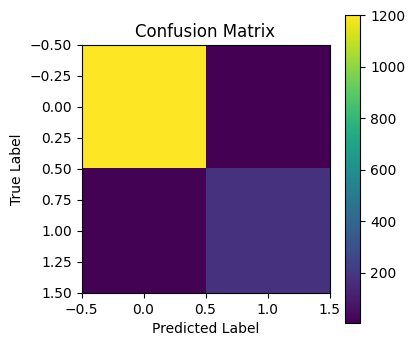

In [14]:
plt.figure(figsize=(4,4))
plt.imshow(confusion_matrix(y_test, y_pred))
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


- Visual representation of classification results

**13. Test with Custom Message**

In [15]:
sample_message = ["Congratulations! You won a free ticket. Click now!"]
sample_vec = vectorizer.transform(sample_message)
prediction = model.predict(sample_vec)

print("Spam" if prediction[0] == 1 else "Not Spam")


Spam


- Allows real-time testing
- Demonstrates practical use

**14. Key Takeaways**

- Spam detection is a classification problem
- Text data must be vectorized
- Naive Bayes is effective for NLP
- Evaluation metrics matter beyond accuracy